In [4]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2) (2).zip


In [5]:
import zipfile

zip_ref = zipfile.ZipFile("archive (2).zip", 'r')
zip_ref.extractall("dataset")
zip_ref.close()

In [6]:
import os

os.listdir("dataset")

['train']

In [7]:
import os

os.listdir("dataset/train")

['eksim', 'panu', 'acne', 'herpes', 'rosacea']

In [8]:
import os
import pandas as pd

data = []

base_path = "dataset/train"

for label in os.listdir(base_path):
    folder_path = os.path.join(base_path, label)

    for img in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img)

        data.append([img_path, label])

df = pd.DataFrame(data, columns=["image_path", "label"])

df.head()

,image_path,label
0,dataset/train/eksim/ek68_jpg.rf.4f841eb2f2255f...,eksim
1,dataset/train/eksim/ek21_jpg.rf.2f7f2e71457012...,eksim
2,dataset/train/eksim/ek70_jpg.rf.9d0b437c8425ef...,eksim
3,dataset/train/eksim/ek19_jpg.rf.8f8694653895c3...,eksim
4,dataset/train/eksim/ek5_jpg.rf.d1421888c873f6f...,eksim


In [9]:
df.to_csv("skin_dataset.csv", index=False)

In [10]:
os.listdir()

['.config',
 'archive (2).zip',
 '5b.jpg',
 'archive (2) (2).zip',
 'skin_dataset.csv',
 'archive (2) (1).zip',
 'dataset',
 'sample_data']

In [11]:
import tensorflow as tf
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [12]:
le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df["label"])

df.head()

,image_path,label,label_encoded
0,dataset/train/eksim/ek68_jpg.rf.4f841eb2f2255f...,eksim,1
1,dataset/train/eksim/ek21_jpg.rf.2f7f2e71457012...,eksim,1
2,dataset/train/eksim/ek70_jpg.rf.9d0b437c8425ef...,eksim,1
3,dataset/train/eksim/ek19_jpg.rf.8f8694653895c3...,eksim,1
4,dataset/train/eksim/ek5_jpg.rf.d1421888c873f6f...,eksim,1


In [13]:
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'acne': np.int64(0), 'eksim': np.int64(1), 'herpes': np.int64(2), 'panu': np.int64(3), 'rosacea': np.int64(4)}


In [14]:
IMG_SIZE = 224

images = []
labels = []

for i in range(len(df)):

    img = cv2.imread(df["image_path"][i])
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0

    images.append(img)
    labels.append(df["label_encoded"][i])

X = np.array(images)
y = np.array(labels)

print(X.shape)
print(y.shape)

(1494, 224, 224, 3)
(1494,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

Training images: (1195, 224, 224, 3)
Testing images: (299, 224, 224, 3)


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(5, activation='softmax')   # 5 diseases
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=15,   # ⬅️ increase a bit
    batch_size=32
)

Epoch 1/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 15s 212ms/step - accuracy: 0.2226 - loss: 1.7925 - val_accuracy: 0.2876 - val_loss: 1.5421
Epoch 2/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.3155 - loss: 1.5028 - val_accuracy: 0.4114 - val_loss: 1.4774
Epoch 3/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.3967 - loss: 1.4287 - val_accuracy: 0.4247 - val_loss: 1.3914
Epoch 4/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.4402 - loss: 1.3043 - val_accuracy: 0.4716 - val_loss: 1.2922
Epoch 5/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.5188 - loss: 1.1712 - val_accuracy: 0.5017 - val_loss: 1.2171
Epoch 6/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.5623 - loss: 1.0651 - val_accuracy: 0.5318 - val_loss: 1.2288
Epoch 7/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.6494 - loss: 0.8987 - val_accuracy: 0.5117 - val_loss: 1.2347
Epoch 8/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.6828 - loss: 0.8156 - val_accuracy: 0.5585 -

In [18]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=32
)

Epoch 1/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - accuracy: 0.9038 - loss: 0.3082 - val_accuracy: 0.5786 - val_loss: 1.6905
Epoch 2/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9230 - loss: 0.2484 - val_accuracy: 0.5786 - val_loss: 1.9184
Epoch 3/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.9138 - loss: 0.2515 - val_accuracy: 0.5920 - val_loss: 2.0074
Epoch 4/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.9347 - loss: 0.1972 - val_accuracy: 0.5920 - val_loss: 2.2018
Epoch 5/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.9523 - loss: 0.1412 - val_accuracy: 0.5819 - val_loss: 2.2221
Epoch 6/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.9247 - loss: 0.2564 - val_accuracy: 0.5853 - val_loss: 2.0947
Epoch 7/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9456 - loss: 0.1868 - val_accuracy: 0.5987 - val_loss: 2.1353
Epoch 8/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.9590 - loss: 0.1316 - val_accuracy: 0.5953 - 

In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [22]:
history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    validation_data=(X_test, y_test_cat),
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

NameError: name 'y_train_cat' is not defined

In [23]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

In [24]:
print(y_train_cat.shape)

(1195, 5)


In [25]:
history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    validation_data=(X_test, y_test_cat),
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30


ValueError: Argument `output` must have rank (ndim) `target.ndim - 1`. Received: target.shape=(None, 5), output.shape=(None, 5)

In [26]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',   # ✅ FIX HERE
    metrics=['accuracy']
)

In [27]:
history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    validation_data=(X_test, y_test_cat),
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 431ms/step - accuracy: 0.4192 - loss: 2.2256 - val_accuracy: 0.5284 - val_loss: 1.2220 - learning_rate: 0.0010
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 361ms/step - accuracy: 0.4929 - loss: 1.3043 - val_accuracy: 0.5886 - val_loss: 1.0642 - learning_rate: 0.0010
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 358ms/step - accuracy: 0.4937 - loss: 1.2438 - val_accuracy: 0.6789 - val_loss: 0.9816 - learning_rate: 0.0010
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 379ms/step - accuracy: 0.5146 - loss: 1.1910 - val_accuracy: 0.6087 - val_loss: 1.0038 - learning_rate: 0.0010
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 359ms/step - accuracy: 0.5523 - loss: 1.1165 - val_accuracy: 0.6555 - val_loss: 0.9834 - learning_rate: 0.0010
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 370ms/step - accuracy: 0.5439 - loss: 1.1150 - val_accuracy: 0.6823 - val_loss: 0.9152 - learning_rate: 0.0010
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 357ms/step - accuracy: 0.5573 - loss: 1.

In [28]:
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test_cat, axis=1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step


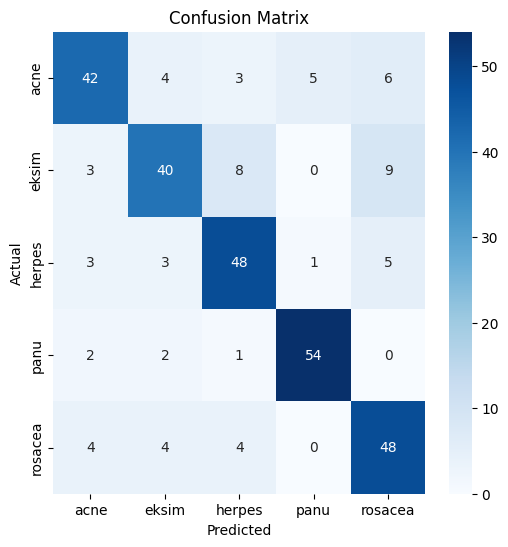

In [29]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [30]:
print(classification_report(y_true, y_pred_classes, target_names=le.classes_))

              precision    recall  f1-score   support

        acne       0.78      0.70      0.74        60
       eksim       0.75      0.67      0.71        60
      herpes       0.75      0.80      0.77        60
        panu       0.90      0.92      0.91        59
     rosacea       0.71      0.80      0.75        60

    accuracy                           0.78       299
   macro avg       0.78      0.78      0.78       299
weighted avg       0.78      0.78      0.77       299



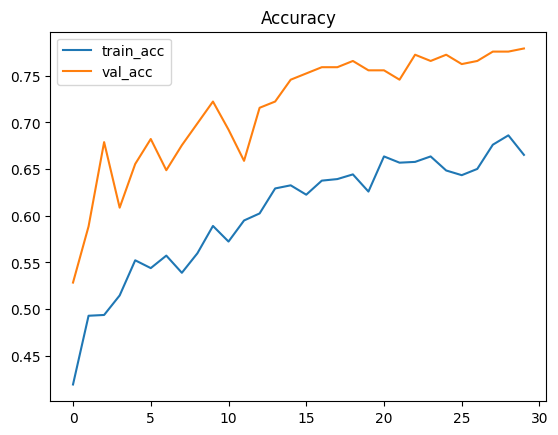

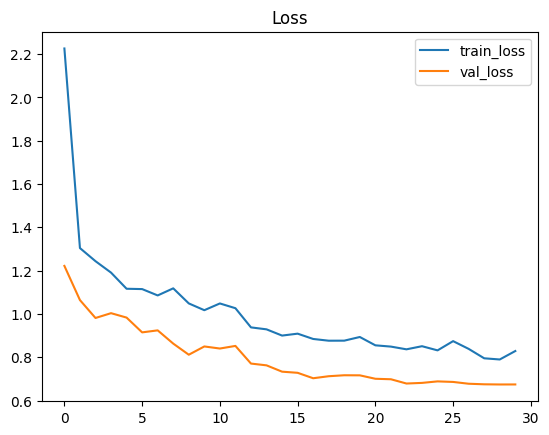

In [31]:
# Accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()

In [32]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


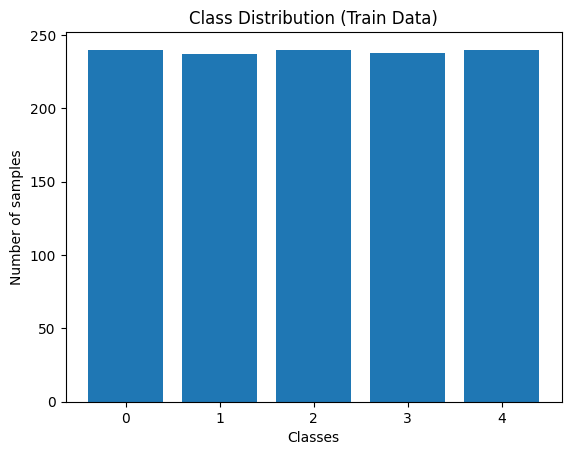

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Count class distribution
unique, counts = np.unique(y_train, return_counts=True)

# Plot
plt.figure()
plt.bar(unique, counts)
plt.xticks(unique)
plt.xlabel("Classes")
plt.ylabel("Number of samples")
plt.title("Class Distribution (Train Data)")
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 792ms/step


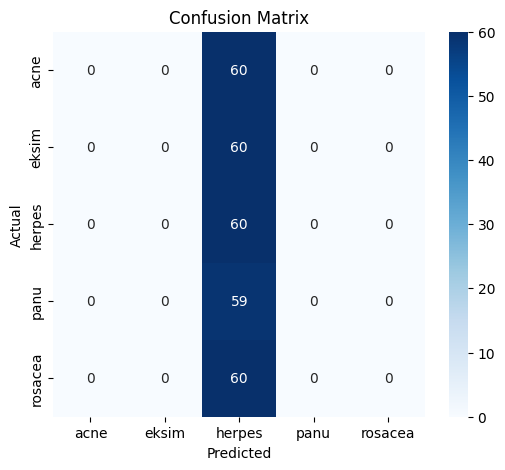

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# If y_test is one-hot encoded → convert
if len(y_test.shape) > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Class names
class_names = ['acne', 'eksim', 'herpes', 'panu', 'rosacea']

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()